In [1]:
!pip install sentence-transformers

In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
sentences = [
    # Cricket (3+)
    "The batsman scored a century in the match",
    "The bowler took a wicket in the final over",
    "Cricket is played with a bat and ball",

    # Cooking (3+)
    "Add salt and spices while cooking curry",
    "Boil the vegetables before frying them",
    "Cooking requires patience and proper ingredients",

    # Cybersecurity (4)
    "Use strong passwords to protect your accounts",
    "Cyber attacks can compromise sensitive data",
    "Firewalls help prevent unauthorized access",
    "Encryption secures data during transmission"
]

In [7]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
similarity_matrix = cosine_similarity(embeddings)

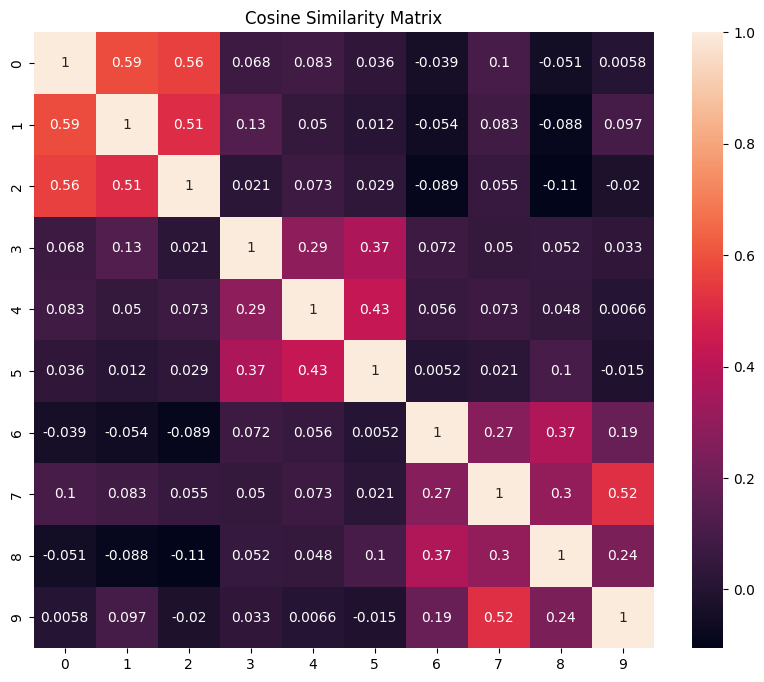

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True)
plt.title("Cosine Similarity Matrix")
plt.show()

In [12]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

In [13]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

scores = cosine_similarity(query_embedding, embeddings)[0]

# Convert to numpy array (important fix)
scores = np.array(scores)

# Get top 2 matches
top_indices = scores.argsort()[-2:][::-1]

for i in top_indices:
    print("Sentence:", sentences[i])
    print("Similarity Score:", scores[i])
    print()

Sentence: The bowler took a wicket in the final over
Similarity Score: 0.83883524

Sentence: The batsman scored a century in the match
Similarity Score: 0.56821966

